In [54]:
# 解决matplotlib中文显示乱码问题
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
import platform

# 设置中文字体
def setup_chinese_font():
    """设置matplotlib中文字体"""
    system = platform.system()
    
    if system == "Windows":
        # Windows系统常用中文字体
        font_candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    elif system == "Darwin":  # macOS
        font_candidates = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC']
    else:  # Linux
        font_candidates = ['WenQuanYi Micro Hei', 'DejaVu Sans']
    
    for font_name in font_candidates:
        try:
            # 测试字体是否可用
            plt.rcParams['font.sans-serif'] = [font_name]
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
            
            # 测试绘图
            fig, ax = plt.subplots(figsize=(1, 1))
            ax.text(0.5, 0.5, '测试中文', fontsize=12, ha='center')
            plt.close(fig)
            
            print(f"成功设置中文字体: {font_name}")
            return True
        except:
            continue
    
    print("警告: 未找到合适的中文字体，可能仍会出现乱码")
    return False

# 运行字体设置
setup_chinese_font()

# 显示当前字体设置
print(f"当前字体设置: {plt.rcParams['font.sans-serif']}")
print(f"负号显示设置: {plt.rcParams['axes.unicode_minus']}")


成功设置中文字体: SimHei
当前字体设置: ['SimHei']
负号显示设置: False


In [61]:
import numpy as np
from scipy.stats import norm, truncnorm
from scipy.integrate import tplquad, quad, dblquad
import matplotlib.pyplot as plt
import time

# --- 参数定义 ---
# 正态分布参数 (矩形中心点)
mean = 0
std_dev = 120

# 矩形尺寸
length = 100
width = 20
height = 25
half_length = length / 2
half_width = width / 2
half_depth = height / 2


# 积分圆形半径
R = 20

# --- 定义概率密度函数 ---
# X, Y方向的概率计算函数
rv_norm_x = norm(loc=mean, scale=std_dev)
rv_norm_y = norm(loc=mean, scale=std_dev)

probx = lambda x: rv_norm_x.pdf(x)
proby = lambda y: rv_norm_y.pdf(y)

prob_x = lambda x: rv_norm_x.cdf(x + half_length) - rv_norm_x.cdf(x - half_length)
prob_y = lambda y: rv_norm_y.cdf(y + half_width) - rv_norm_y.cdf(y - half_width)

# --- 目标函数 I 的定义 ---
# 基于上述分析，我们设定 x0 = 0, y0 = 0
# x0 = 0
# y0 = 0

# 因为 Xc 和 Yc 是独立的, 总概率是两个方向概率的乘积

# def Z1(x, y):
#     return prob_x(x) * prob_y(y) #/ (width * length)

def Z0(x, y):
    return probx(x) * proby(y) 




In [79]:
# --- 计算圆形区域内的积分 ---
print("开始计算 Z 在圆形区域内的积分...")
print(f"圆形区域：以原点为圆心，半径 R = {R}")

# 方法1：使用笛卡尔坐标系的二重积分
# 积分区域：x² + y² ≤ R²
# x 从 -R 到 R，y 从 -√(R²-x²) 到 √(R²-x²)

def y_lower(x):
    """y的下界"""
    if x > half_length:
        return -np.sqrt(R**2 - (x-half_length)**2) - half_width
    elif x < -half_length:
        return -np.sqrt(R**2 - (x+half_length)**2) - half_width
    else:
        return -half_width - R

def y_upper(x):
    """y的上界"""
    if x > half_length:
        return np.sqrt(R**2 - (x-half_length)**2) + half_width
    elif x < -half_length:
        return np.sqrt(R**2 - (x+half_length)**2) + half_width
    else:
        return half_width + R
    

def dbl(z):
    if z < 117.5:
        return 0
    elif z < 137.5:
        rr = np.sqrt(R**2 - (137.5-z)**2)
    elif z < 162.5:
        rr = R
    elif z < 182.5:
        rr = np.sqrt(R**2 - (162.5-z)**2)
    else:
        
        return dblquad(Z0, -half_length, half_length, -half_width, half_width)[0]

    #start_time = time.time()

    result, error = dblquad(Z0, -rr-half_length, rr+half_length, y_lower, y_upper)
    return result

z_values = np.linspace(100, 200, 200)
results = []

for z in z_values:
    result = dbl(z)
    results.append(result)
    print(f"z = {z:.1f}, 积分结果 = {result:.6f}")

# 转换为numpy数组便于绘图
z_values = np.array(z_values)
results = np.array(results)

print("-" * 50)




开始计算 Z 在圆形区域内的积分...
圆形区域：以原点为圆心，半径 R = 20
z = 100.0, 积分结果 = 0.000000
z = 100.5, 积分结果 = 0.000000
z = 101.0, 积分结果 = 0.000000
z = 101.5, 积分结果 = 0.000000
z = 102.0, 积分结果 = 0.000000
z = 102.5, 积分结果 = 0.000000
z = 103.0, 积分结果 = 0.000000
z = 103.5, 积分结果 = 0.000000
z = 104.0, 积分结果 = 0.000000
z = 104.5, 积分结果 = 0.000000
z = 105.0, 积分结果 = 0.000000
z = 105.5, 积分结果 = 0.000000
z = 106.0, 积分结果 = 0.000000
z = 106.5, 积分结果 = 0.000000
z = 107.0, 积分结果 = 0.000000
z = 107.5, 积分结果 = 0.000000
z = 108.0, 积分结果 = 0.000000
z = 108.5, 积分结果 = 0.000000
z = 109.0, 积分结果 = 0.000000
z = 109.5, 积分结果 = 0.000000
z = 110.1, 积分结果 = 0.000000
z = 110.6, 积分结果 = 0.000000
z = 111.1, 积分结果 = 0.000000
z = 111.6, 积分结果 = 0.000000
z = 112.1, 积分结果 = 0.000000
z = 112.6, 积分结果 = 0.000000
z = 113.1, 积分结果 = 0.000000
z = 113.6, 积分结果 = 0.000000
z = 114.1, 积分结果 = 0.000000
z = 114.6, 积分结果 = 0.000000
z = 115.1, 积分结果 = 0.000000
z = 115.6, 积分结果 = 0.000000
z = 116.1, 积分结果 = 0.000000
z = 116.6, 积分结果 = 0.000000
z = 117.1, 积分结果 = 0.000000
z = 117.6, 积分

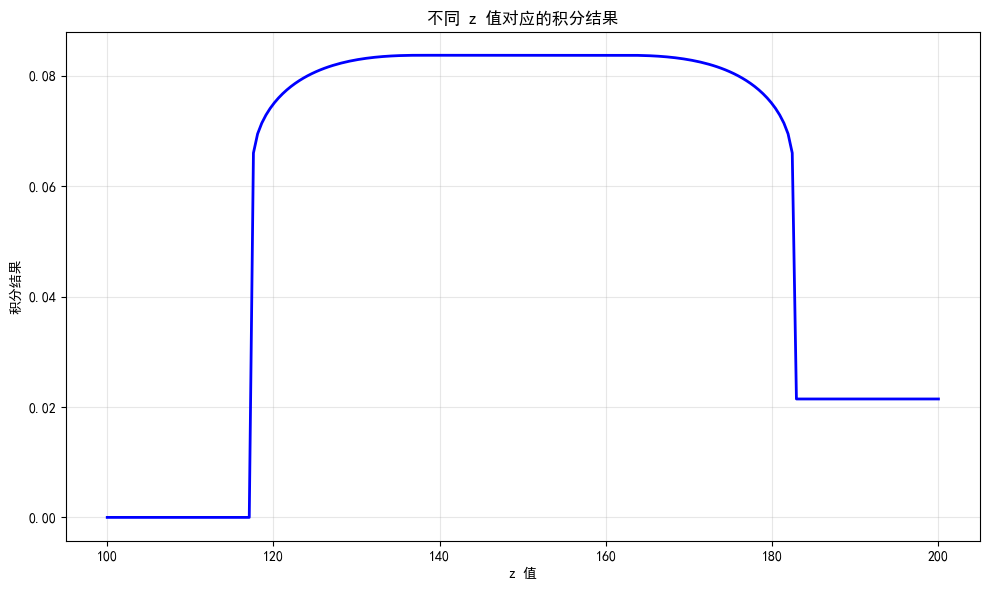

最大积分值: 0.083734
对应的z值: 137.7


In [80]:

# 绘制结果图
plt.figure(figsize=(10, 6))
plt.plot(z_values, results, 'b-', linewidth=2, markersize=4)
plt.xlabel('z 值')
plt.ylabel('积分结果')
plt.title('不同 z 值对应的积分结果')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 显示最大值及其对应的z值
max_idx = np.argmax(results)
print(f"最大积分值: {results[max_idx]:.6f}")
print(f"对应的z值: {z_values[max_idx]:.1f}")

矩形区域积分结果: 0.021457


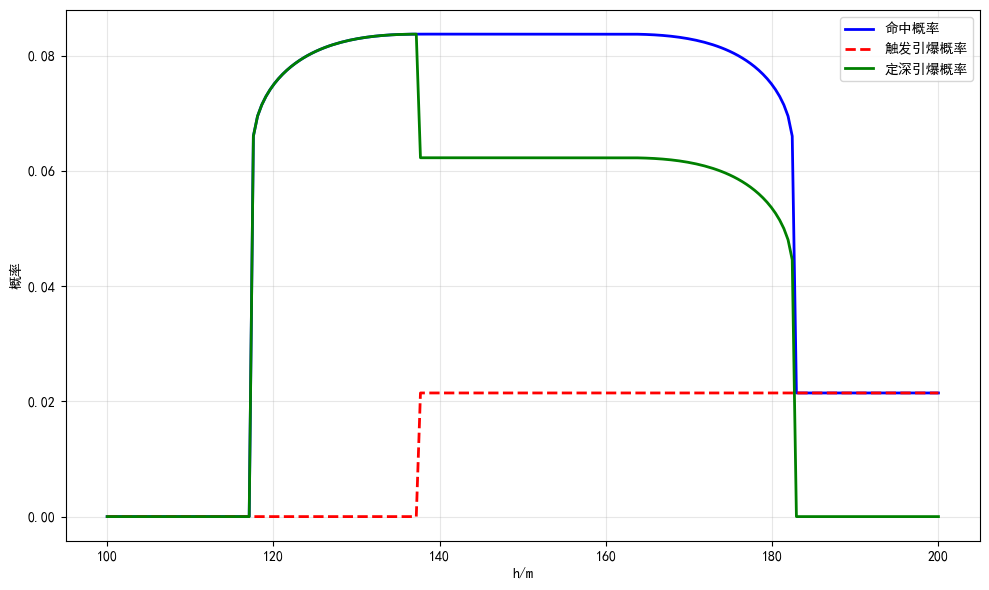

最大积分值: 0.083734
对应的z值: 137.7


In [93]:
# 计算矩形区域的积分结果作为参考线
result2, _ = dblquad(Z0, -half_length, half_length, -half_width, half_width)
print(f"矩形区域积分结果: {result2:.6f}")

# 创建第二条线：z_values>=137.5时等于result2，否则为0
result2_line = np.where(z_values >= 137.5, result2, 0)

# 绘制结果图
plt.figure(figsize=(10, 6))
plt.plot(z_values, results, 'b-', linewidth=2, label='命中概率')
plt.plot(z_values, result2_line, 'r--', linewidth=2, label='触发引爆概率')
plt.plot(z_values, results - result2_line, 'g-', linewidth=2, label='定深引爆概率')
plt.xlabel('h/m')
plt.ylabel('概率')
#
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 显示最大值及其对应的z值
max_idx = np.argmax(results)
print(f"最大积分值: {results[max_idx]:.6f}")
print(f"对应的z值: {z_values[max_idx]:.1f}")